In [130]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
  
from sklearn.preprocessing import PowerTransformer

In [131]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [132]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [133]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [134]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [135]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [136]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [137]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [138]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [139]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [140]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [141]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [142]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [143]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [144]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [145]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Yeo-Johnson Transformation for Clustering

In [146]:
original_X = X.copy()

In [147]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_numeric_std = pt.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

In [148]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.785036,1,0,1,0,0,1,0.0,0,-1.533345,0.0,0.750782,0.080033,0.343545
1,-0.746998,0,0,0,0,1,0,0.0,1,0.397233,0.0,-1.213660,-1.722060,-1.657833
2,-0.175256,0,1,0,0,0,1,0.0,1,0.830437,1.0,-0.474112,0.735716,0.318631
3,1.371631,0,0,0,0,1,0,0.0,1,0.727938,0.0,-1.992620,-1.291020,-1.835650
4,0.987008,0,0,0,0,1,0,0.0,1,1.144253,0.0,-1.106304,-0.816679,-1.003396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.007949,0,0,1,0,0,1,1.0,0,-1.533345,0.0,-0.158214,-0.822461,-0.611074
135,1.111443,0,0,1,0,0,1,1.0,0,-1.533345,1.0,-0.632361,1.008070,0.474941
136,-0.370651,0,0,1,0,0,1,1.0,1,0.786825,0.0,0.658564,-0.170908,0.133612
137,0.696583,0,0,1,0,0,1,1.0,1,1.554125,1.0,-0.551725,0.574668,0.197985


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

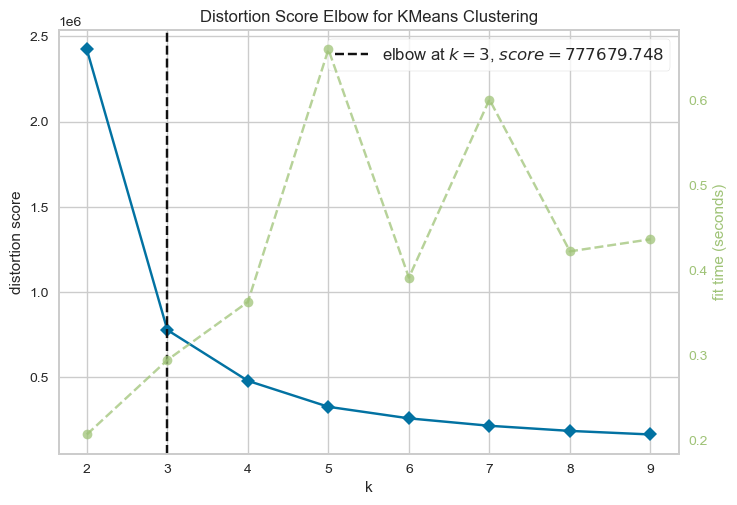

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [149]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [150]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=3)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: MTV, Coefficient: 0.3754239928511034


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: uicc8_III-IV, Coefficient: 1.1438218920688954


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 2: Most important feature: hpv_related, Coefficient: -1.3994025496184521


In [152]:
selected_features

['MTV', 'uicc8_III-IV', 'hpv_related']

In [153]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Yeo-Johnson Transformation

In [159]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)
X_new_std = X_new_std[X_new.columns]

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [160]:
X_new

,MTV,uicc8_III-IV,hpv_related
0,7.934,0.0,0.0
1,1.656,0.0,0.0
2,14.502,1.0,0.0
3,2.440,0.0,0.0
4,3.668,0.0,0.0
...,...,...,...
134,3.650,0.0,1.0
135,18.967,1.0,1.0
136,6.370,0.0,1.0
137,12.443,1.0,1.0


In [161]:
X_new_std

,MTV,uicc8_III-IV,hpv_related
0,0.080033,0.0,0.0
1,-1.722060,0.0,0.0
2,0.735716,1.0,0.0
3,-1.291020,0.0,0.0
4,-0.816679,0.0,0.0
...,...,...,...
134,-0.822461,0.0,1.0
135,1.008070,1.0,1.0
136,-0.170908,0.0,1.0
137,0.574668,1.0,1.0


In [162]:
MAASTRO_new

,MTV,uicc8_III-IV,hpv_related
0,22.841,0,1
1,5.660,1,0
2,7.791,1,0
3,7.908,1,0
4,15.237,0,1
...,...,...,...
94,6.110,1,0
95,7.182,1,0
96,16.483,1,1
97,9.981,0,1


In [163]:
MAASTRO_new_std

,MTV,uicc8_III-IV,hpv_related
0,1.188930,0,1
1,-0.307894,1,0
2,0.059450,1,0
3,0.076321,1,0
4,0.786849,0,1
...,...,...,...
94,-0.219083,1,0
95,-0.033134,1,0
96,0.867254,1,1
97,0.336049,0,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [164]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:57:30,485] A new study created in memory with name: no-name-5cab9943-2939-426e-963b-661dc408b6a5


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6926406926406926
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784


[I 2024-04-13 23:57:32,241] A new study created in memory with name: no-name-40e56e0f-fc49-463f-92e0-b3c4212c8a16


Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:57:32,216] Trial 0 finished with value: 0.7472855976537036 and parameters: {}. Best is trial 0 with value: 0.7472855976537036.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7472855976537036], datetime_start=datetime.datetime(2024, 4, 13, 23, 57, 30, 797532), datetime_complete=datetime.datetime(2024, 4, 13, 23, 57, 32, 215291), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7472855976537036


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.1601946763771463
Fold 2 IBS: 0.19998963449525187
Fold 3 IBS: 0.16262723253733058
Fold 4 IBS: 0.13901484026347005
Fold 5 IBS: 0.2472748655532124
[I 2024-04-13 23:57:33,984] Trial 0 finished with value: 0.18182024984528225 and parameters: {}. Best is trial 0 with value: 0.18182024984528225.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18182024984528225], datetime_start=datetime.datetime(2024, 4, 13, 23, 57, 32, 515176), datetime_complete=datetime.datetime(2024, 4, 13, 23, 57, 33, 983658), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18182024984528225


In [165]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [166]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.747
train_ibs:  0.182


#### Test

In [167]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [168]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.666
IBS score: 0.227


In [169]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [170]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [171]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:57:34,679] A new study created in memory with name: no-name-4d8c7f17-c3b3-4f63-b123-acd64ef58af2


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5735930735930735
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7009803921568627


[I 2024-04-13 23:57:35,570] A new study created in memory with name: no-name-e2bcaa5a-b194-4db6-be25-d59f45e8e9d1


Fold 4 C-index: 0.7721518987341772
Fold 5 C-index: 0.6338028169014085
[I 2024-04-13 23:57:35,563] Trial 0 finished with value: 0.6753913505628186 and parameters: {}. Best is trial 0 with value: 0.6753913505628186.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6753913505628186], datetime_start=datetime.datetime(2024, 4, 13, 23, 57, 34, 710247), datetime_complete=datetime.datetime(2024, 4, 13, 23, 57, 35, 562054), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6753913505628186


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651928857817
Fold 2 IBS: 0.2215779141699564
Fold 3 IBS: 0.20453594043117468
Fold 4 IBS: 0.22473803261462794
Fold 5 IBS: 0.21812431354668568
[I 2024-04-13 23:57:36,810] Trial 0 finished with value: 0.21659054401020458 and parameters: {}. Best is trial 0 with value: 0.21659054401020458.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054401020458], datetime_start=datetime.datetime(2024, 4, 13, 23, 57, 35, 888668), datetime_complete=datetime.datetime(2024, 4, 13, 23, 57, 36, 809662), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054401020458


In [172]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [173]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.675
train_ibs:  0.217


#### Test

In [174]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [175]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.664


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [176]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [177]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:57:37,466] A new study created in memory with name: no-name-8adf261c-eef9-48b7-84c7-3999800ddce5


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.7455357142857143
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823


[I 2024-04-13 23:57:38,948] A new study created in memory with name: no-name-e6bb5e54-d584-4384-8ca7-4dcf4677adef


Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:57:38,936] Trial 0 finished with value: 0.7455269396450455 and parameters: {}. Best is trial 0 with value: 0.7455269396450455.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7455269396450455], datetime_start=datetime.datetime(2024, 4, 13, 23, 57, 37, 499245), datetime_complete=datetime.datetime(2024, 4, 13, 23, 57, 38, 936154), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7455269396450455


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.16073455390363514
Fold 2 IBS: 0.1998094660212294
Fold 3 IBS: 0.1627825810147773
Fold 4 IBS: 0.14003819640733686
Fold 5 IBS: 0.24569351946332338
[I 2024-04-13 23:57:40,840] Trial 0 finished with value: 0.1818116633620604 and parameters: {}. Best is trial 0 with value: 0.1818116633620604.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.1818116633620604], datetime_start=datetime.datetime(2024, 4, 13, 23, 57, 38, 985859), datetime_complete=datetime.datetime(2024, 4, 13, 23, 57, 40, 838776), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.1818116633620604


In [178]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [179]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.746
train_ibs:  0.182


#### Test

In [180]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [181]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.666


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.225


In [182]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [183]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:57:41,744] A new study created in memory with name: no-name-801c0a0f-a0e7-48d5-a1ec-891784d9fadc


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:57:43,054] Trial 0 finished with value: 0.7464197967879026 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7464197967879026.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:57:44,879] Trial 1 finished with value: 0.7464197967879026 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.7464197967879026.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:57:46,441] Trial 2 finished with value: 0.7464197967879026 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.74641979678

Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:58:32,425] Trial 24 finished with value: 0.7464197967879026 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.7464197967879026.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:58:34,151] Trial 25 finished with value: 0.7464197967879026 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.7464197967879026.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:58:36,762] Trial 26 finished with value: 0.7464197967879026 and parameters: {'l1_ratio': 0.3312072877416866}. Best is trial 0 with value: 0.7464197967879026.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.82278481

Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:59:30,670] Trial 49 finished with value: 0.7464197967879026 and parameters: {'l1_ratio': 0.7153190338760974}. Best is trial 0 with value: 0.7464197967879026.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:59:33,571] Trial 50 finished with value: 0.7464197967879026 and parameters: {'l1_ratio': 0.5027665121167861}. Best is trial 0 with value: 0.7464197967879026.
Fold 1 C-index: 0.6883116883116883
Fold 2 C-index: 0.75
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:59:35,654] Trial 51 finished with value: 0.7464197967879026 and parameters: {'l1_ratio': 0.4343748320430144}. Best is trial 0 with value: 0.7464197967

...

Fold 1 IBS: 0.16078842810223445
Fold 2 IBS: 0.19932468940397072
Fold 3 IBS: 0.16264462290597198
Fold 4 IBS: 0.14008400003293045
Fold 5 IBS: 0.24543569308799407
[I 2024-04-14 00:01:41,711] Trial 0 finished with value: 0.18165548670662032 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.18165548670662032.
Fold 1 IBS: 0.16083800769353976
Fold 2 IBS: 0.1987439558659352
Fold 3 IBS: 0.16246486573810945
Fold 4 IBS: 0.14007774609446202
Fold 5 IBS: 0.24517996618478644
[I 2024-04-14 00:01:43,831] Trial 1 finished with value: 0.18146090831536657 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.18146090831536657.
Fold 1 IBS: 0.1608722706556597
Fold 2 IBS: 0.1986015830250264
Fold 3 IBS: 0.1624458638040648
Fold 4 IBS: 0.14011803654993568
Fold 5 IBS: 0.2452308003980171
[I 2024-04-14 00:01:46,115] Trial 2 finished with value: 0.18145371088654075 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.18145371088654

Fold 1 IBS: 0.1609114503406324
Fold 2 IBS: 0.19843138012639366
Fold 3 IBS: 0.16237059907547188
Fold 4 IBS: 0.1401330918216383
Fold 5 IBS: 0.24502733409733157
[I 2024-04-14 00:02:39,994] Trial 25 finished with value: 0.18137477109229355 and parameters: {'l1_ratio': 0.05931545709357716}. Best is trial 25 with value: 0.18137477109229355.
Fold 1 IBS: 0.21357554717428562
Fold 2 IBS: 0.22112010799670712
Fold 3 IBS: 0.2035038135951228
Fold 4 IBS: 0.22341734469843716
Fold 5 IBS: 0.24509735117759934
[I 2024-04-14 00:02:41,200] Trial 26 finished with value: 0.22134283292843043 and parameters: {'l1_ratio': 0.015423757551295547}. Best is trial 25 with value: 0.18137477109229355.
Fold 1 IBS: 0.16085498987477223
Fold 2 IBS: 0.19864120231042173
Fold 3 IBS: 0.16243913296980297
Fold 4 IBS: 0.14009179966110605
Fold 5 IBS: 0.2450961506973554
[I 2024-04-14 00:02:43,323] Trial 27 finished with value: 0.18142465510269168 and parameters: {'l1_ratio': 0.23266740627482266}. Best is trial 25 with value: 0.18137

Fold 5 IBS: 0.2450475413855013
[I 2024-04-14 00:03:35,328] Trial 49 finished with value: 0.18137861611100378 and parameters: {'l1_ratio': 0.05987602124246412}. Best is trial 42 with value: 0.18137201392982316.
Fold 1 IBS: 0.16081949273700194
Fold 2 IBS: 0.19916589348089736
Fold 3 IBS: 0.1626059202759362
Fold 4 IBS: 0.14012047038149342
Fold 5 IBS: 0.24544511789508708
[I 2024-04-14 00:03:37,419] Trial 50 finished with value: 0.1816313789540832 and parameters: {'l1_ratio': 0.6064718647459368}. Best is trial 42 with value: 0.18137201392982316.
Fold 1 IBS: 0.16093061320626548
Fold 2 IBS: 0.19839211827888295
Fold 3 IBS: 0.1623648886978847
Fold 4 IBS: 0.1401618433528064
Fold 5 IBS: 0.24516621012591971
[I 2024-04-14 00:03:40,213] Trial 51 finished with value: 0.18140313473235187 and parameters: {'l1_ratio': 0.05779933799245819}. Best is trial 42 with value: 0.18137201392982316.
Fold 1 IBS: 0.21387140429875343
Fold 2 IBS: 0.22145864477023774
Fold 3 IBS: 0.20426448226833938
Fold 4 IBS: 0.2243915

Fold 1 IBS: 0.16087879638466437
Fold 2 IBS: 0.19854293274773482
Fold 3 IBS: 0.1623943693983127
Fold 4 IBS: 0.1400939003909023
Fold 5 IBS: 0.24514432292614713
[I 2024-04-14 00:04:26,902] Trial 74 finished with value: 0.18141086436955228 and parameters: {'l1_ratio': 0.09850450910152567}. Best is trial 42 with value: 0.18137201392982316.
Fold 1 IBS: 0.21322199463551875
Fold 2 IBS: 0.1984616726364767
Fold 3 IBS: 0.16236862691991957
Fold 4 IBS: 0.22225612143433296
Fold 5 IBS: 0.24511093031963554
[I 2024-04-14 00:04:28,553] Trial 75 finished with value: 0.2082838691891767 and parameters: {'l1_ratio': 0.029635839760907487}. Best is trial 42 with value: 0.18137201392982316.
Fold 1 IBS: 0.16087257389082746
Fold 2 IBS: 0.19858031256509248
Fold 3 IBS: 0.16240395547119288
Fold 4 IBS: 0.1400899183440157
Fold 5 IBS: 0.24517298818403005
[I 2024-04-14 00:04:30,827] Trial 76 finished with value: 0.1814239496910317 and parameters: {'l1_ratio': 0.11947359641830288}. Best is trial 42 with value: 0.1813720

Fold 5 IBS: 0.2451858217588714
[I 2024-04-14 00:05:13,937] Trial 98 finished with value: 0.18140615022048495 and parameters: {'l1_ratio': 0.1314136700408577}. Best is trial 81 with value: 0.1813694681367654.
Fold 1 IBS: 0.16091983269663415
Fold 2 IBS: 0.1984821657767391
Fold 3 IBS: 0.16238936329353407
Fold 4 IBS: 0.1401611704779108
Fold 5 IBS: 0.24503013294067297
[I 2024-04-14 00:05:15,976] Trial 99 finished with value: 0.1813965330370982 and parameters: {'l1_ratio': 0.11186239298945089}. Best is trial 81 with value: 0.1813694681367654.


* Best trial for IBS: 
 FrozenTrial(number=81, state=TrialState.COMPLETE, values=[0.1813694681367654], datetime_start=datetime.datetime(2024, 4, 14, 0, 4, 37, 886687), datetime_complete=datetime.datetime(2024, 4, 14, 0, 4, 40, 27381), params={'l1_ratio': 0.05855636044160524}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=81, value=None)


* Be

In [184]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [185]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.746
train_ibs:  0.181


#### Test

In [186]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [187]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.666


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.05855636044160524)

test_ibs:  0.225


In [188]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [189]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 00:05:17,153] A new study created in memory with name: no-name-76fcb12e-4a3c-4437-a07f-a072ec1d15e6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6796536796536796
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.8112745098039216
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:05:31,480] Trial 0 finished with value: 0.7458339221116087 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7458339221116087.
Fold 1 C-index: 0.7207792207792207
Fold 2 C-index: 0.7611607142857143
Fold 3 C-index: 0.7377450980392157
Fold 4 C-index: 0.820675105485232
Fold 5 C-index: 0.6830985915492958
[I 2024-04-14 00:05:43,791] Trial 1 finished with value: 0.7446917460277357 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 3 C-index: 0.8161764705882353
Fold 4 C-index: 0.8481012658227848
Fold 5 C-index: 0.6455399061032864
[I 2024-04-14 00:08:11,311] Trial 15 finished with value: 0.7597449137842467 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 385, 'oob_score': True, 'max_samples': 0.44567908834749126, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1651092422125184, 'warm_start': True}. Best is trial 14 with value: 0.7629463674236125.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:08:19,534] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 17, 'min_samples_leaf': 18, 'max_depth': 1, 'n_estimators': 422, 'oob_score': True, 'max_samples': 0.36871324569404207, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.18198533854133878, 'warm_start': True}. Best is trial 14 with value: 0.7629463674236125.
Fold 1 C-inde

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:10:25,106] Trial 30 finished with value: 0.5 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 11, 'min_samples_leaf': 12, 'max_depth': 8, 'n_estimators': 338, 'oob_score': True, 'max_samples': 0.6847549346025055, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.3843088343404539, 'warm_start': True}. Best is trial 25 with value: 0.7848984333923849.
Fold 1 C-index: 0.7337662337662337
Fold 2 C-index: 0.7745535714285714
Fold 3 C-index: 0.7892156862745098
Fold 4 C-index: 0.8670886075949367
Fold 5 C-index: 0.7065727699530516
[I 2024-04-14 00:10:35,882] Trial 31 finished with value: 0.7742393738034606 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 13, 'min_samples_leaf': 14, 'max_depth': 3, 'n_estimators': 467, 'oob_score': True, 'max_samples': 0.7817309736829929, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.19836370070983741, 'warm_start':

...

Fold 1 IBS: 0.1700808874414621
Fold 2 IBS: 0.1957626330898202
Fold 3 IBS: 0.16299225971111658
Fold 4 IBS: 0.14892924315157968
Fold 5 IBS: 0.21740023376964285
[I 2024-04-14 00:42:52,066] Trial 32 finished with value: 0.17903305143272424 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 19, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 168, 'oob_score': True, 'max_samples': 0.9502203520505428, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.09696255694048989}. Best is trial 32 with value: 0.17903305143272424.
Fold 1 IBS: 0.17652829720413224
Fold 2 IBS: 0.19291320934058873
Fold 3 IBS: 0.16957175032984795
Fold 4 IBS: 0.16085480236461036
Fold 5 IBS: 0.21590012980005727
[I 2024-04-14 00:43:03,113] Trial 33 finished with value: 0.1831536378078473 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 4, 'n_estimators': 254, 'oob_score': True, 'max_samples': 0.6330202894947591, 'max_features': 'auto', 'min_weight_fraction_le

Fold 1 IBS: 0.21398609051229583
Fold 2 IBS: 0.22136257722990227
Fold 3 IBS: 0.20485270564707175
Fold 4 IBS: 0.22472651312004177
Fold 5 IBS: 0.218666362427068
[I 2024-04-14 00:44:24,061] Trial 48 finished with value: 0.21671884978727593 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 9, 'n_estimators': 330, 'oob_score': True, 'max_samples': 0.6612069620792733, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.44962767788541247}. Best is trial 34 with value: 0.17851893430396756.
Fold 1 IBS: 0.1900439550758612
Fold 2 IBS: 0.22042025221365688
Fold 3 IBS: 0.16869341419006406
Fold 4 IBS: 0.15240464910754895
Fold 5 IBS: 0.2503258963378386
[I 2024-04-14 00:44:26,111] Trial 49 finished with value: 0.19637763338499395 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 8, 'min_samples_leaf': 1, 'max_depth': 8, 'n_estimators': 31, 'oob_score': True, 'max_samples': 0.7763965552132469, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.17815508719545395
Fold 2 IBS: 0.19099752218170837
Fold 3 IBS: 0.1698970191383925
Fold 4 IBS: 0.1676888498144417
Fold 5 IBS: 0.2122412324573751
[I 2024-04-14 00:45:49,267] Trial 64 finished with value: 0.18379594215747436 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 4, 'n_estimators': 121, 'oob_score': True, 'max_samples': 0.26967029716304014, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.06408448066684834}. Best is trial 34 with value: 0.17851893430396756.
Fold 1 IBS: 0.16699123845792918
Fold 2 IBS: 0.2080394737258576
Fold 3 IBS: 0.16031312909869425
Fold 4 IBS: 0.1452244498490347
Fold 5 IBS: 0.2177004027330441
[I 2024-04-14 00:45:52,636] Trial 65 finished with value: 0.17965373877291196 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 20, 'min_samples_leaf': 2, 'max_depth': 3, 'n_estimators': 85, 'oob_score': False, 'max_samples': 0.5332387486347139, 'max_features': 'auto', 'min_weight_fraction_leaf

Fold 1 IBS: 0.18820736427520215
Fold 2 IBS: 0.18083526506436315
Fold 3 IBS: 0.16795150479175427
Fold 4 IBS: 0.15292026691028499
Fold 5 IBS: 0.22550580767870607
[I 2024-04-14 00:47:24,180] Trial 80 finished with value: 0.18308404174406212 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 2, 'n_estimators': 2, 'oob_score': True, 'max_samples': 0.6412607588874932, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.016423521133014707}. Best is trial 74 with value: 0.1774185092491807.
Fold 1 IBS: 0.16400651664120955
Fold 2 IBS: 0.19308358623525232
Fold 3 IBS: 0.16349993273977678
Fold 4 IBS: 0.15087974320080844
Fold 5 IBS: 0.21633408151691103
[I 2024-04-14 00:47:25,318] Trial 81 finished with value: 0.1775607720667916 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 14, 'min_samples_leaf': 7, 'max_depth': 3, 'n_estimators': 20, 'oob_score': False, 'max_samples': 0.7559506729789947, 'max_features': 'auto', 'min_weight_fraction_le

Fold 5 IBS: 0.21783932119841348
[I 2024-04-14 00:47:47,272] Trial 95 finished with value: 0.18106636143295174 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 3, 'n_estimators': 40, 'oob_score': False, 'max_samples': 0.790995735267869, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.06365580553601909}. Best is trial 84 with value: 0.17715348849887902.
Fold 1 IBS: 0.17032671039035616
Fold 2 IBS: 0.1920085580237801
Fold 3 IBS: 0.1674471473279434
Fold 4 IBS: 0.15169386094624185
Fold 5 IBS: 0.22285309182951205
[I 2024-04-14 00:47:49,465] Trial 96 finished with value: 0.18086587370356672 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 15, 'min_samples_leaf': 8, 'max_depth': 4, 'n_estimators': 52, 'oob_score': False, 'max_samples': 0.8157597557498967, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.05201461552588649}. Best is trial 84 with value: 0.17715348849887902.
Fold 1 IBS: 0.22234616030347362
Fold 2 IBS: 0.1690

In [190]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [191]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.865
train_ibs:  0.177


#### Test

In [192]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [193]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=10, max_features='auto', max_leaf_nodes=19,
                     max_samples=0.7326721556570275, min_samples_leaf=1,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.0005821684937764825,
                     n_estimators=201, random_state=123, warm_start=True)

test_cindex:  0.648


RandomSurvivalForest(max_depth=3, max_features='auto', max_leaf_nodes=14,
                     max_samples=0.7605987399634462, min_samples_leaf=8,
                     min_samples_split=16,
                     min_weight_fraction_leaf=0.03545437941861377,
                     n_estimators=23, random_state=123)

test_ibs:  0.207


In [194]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [195]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:47:56,322] A new study created in memory with name: no-name-1144f9c6-cbcd-4678-b3a4-02388eac5a47


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6991341991341992
Fold 2 C-index: 0.7678571428571429
Fold 3 C-index: 0.821078431372549
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6408450704225352
[I 2024-04-14 00:47:59,112] Trial 0 finished with value: 0.753715458208762 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.753715458208762.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:48:06,040] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}. 

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:49:10,729] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 20, 'min_samples_leaf': 14, 'max_depth': 4, 'n_estimators': 188, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.10487362176361337, 'min_weight_fraction_leaf': 0.3520235308888131}. Best is trial 13 with value: 0.7641280306673635.
Fold 1 C-index: 0.7121212121212122
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8438818565400844
Fold 5 C-index: 0.636150234741784
[I 2024-04-14 00:49:11,800] Trial 17 finished with value: 0.7565329015769746 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 16, 'min_samples_leaf': 19, 'max_depth': 4, 'n_estimators': 80, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.9007791672163892, 'min_weight_fraction_leaf': 0.2092418530672

Fold 1 C-index: 0.7337662337662337
Fold 2 C-index: 0.7745535714285714
Fold 3 C-index: 0.8161764705882353
Fold 4 C-index: 0.8628691983122363
Fold 5 C-index: 0.6549295774647887
[I 2024-04-14 00:49:49,153] Trial 31 finished with value: 0.7684590103120131 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 6, 'n_estimators': 120, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6259360835025306, 'min_weight_fraction_leaf': 0.05314349204291686}. Best is trial 30 with value: 0.7699431971973543.
Fold 1 C-index: 0.6991341991341992
Fold 2 C-index: 0.7790178571428571
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8375527426160337
Fold 5 C-index: 0.6244131455399061
[I 2024-04-14 00:49:50,180] Trial 32 finished with value: 0.7527294712395404 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 19, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 92, 'oob_score': False, 'warm_start': True, 'max_featur

...

Fold 1 IBS: 0.17033312999217434
Fold 2 IBS: 0.19916696903794984
Fold 3 IBS: 0.17329409096630852
Fold 4 IBS: 0.17025831616904066
Fold 5 IBS: 0.22032039621531396
[I 2024-04-14 01:02:11,583] Trial 30 finished with value: 0.18667458047615745 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 19, 'min_samples_leaf': 6, 'max_depth': 3, 'n_estimators': 267, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.8382504072008882, 'min_weight_fraction_leaf': 0.13588619166501759}. Best is trial 18 with value: 0.18302407398255077.
Fold 1 IBS: 0.16387977719599225
Fold 2 IBS: 0.20294047399497242
Fold 3 IBS: 0.16974979946266672
Fold 4 IBS: 0.1599506719289871
Fold 5 IBS: 0.2220294940184522
[I 2024-04-14 01:02:19,362] Trial 31 finished with value: 0.18371004332021412 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 19, 'min_samples_leaf': 5, 'max_depth': 6, 'n_estimators': 267, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.92

Fold 1 IBS: 0.16403809599056546
Fold 2 IBS: 0.2008194488388515
Fold 3 IBS: 0.16634832520347434
Fold 4 IBS: 0.15652934554365014
Fold 5 IBS: 0.2228125139092683
[I 2024-04-14 01:04:13,640] Trial 45 finished with value: 0.18210954589716194 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 2, 'n_estimators': 134, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.7616416445752097, 'min_weight_fraction_leaf': 0.018062380310101427}. Best is trial 44 with value: 0.1819359787149974.
Fold 1 IBS: 0.1628012705872472
Fold 2 IBS: 0.2009529268812392
Fold 3 IBS: 0.16631599067382893
Fold 4 IBS: 0.15560659797088594
Fold 5 IBS: 0.22302747334934572
[I 2024-04-14 01:04:16,318] Trial 46 finished with value: 0.18174085189250938 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 83, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.744630674

Fold 1 IBS: 0.1626577328791172
Fold 2 IBS: 0.20084736248743987
Fold 3 IBS: 0.16664158903453302
Fold 4 IBS: 0.1552217475463327
Fold 5 IBS: 0.22435474792019608
[I 2024-04-14 01:04:50,320] Trial 60 finished with value: 0.18194463597352376 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 15, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 74, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.8159963018809403, 'min_weight_fraction_leaf': 0.0017686619744721153}. Best is trial 57 with value: 0.18009849926473462.
Fold 1 IBS: 0.16267732438570223
Fold 2 IBS: 0.20076386537753022
Fold 3 IBS: 0.16633343468818076
Fold 4 IBS: 0.1552668970374797
Fold 5 IBS: 0.22435474792019608
[I 2024-04-14 01:04:52,909] Trial 61 finished with value: 0.1818792538818178 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 15, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 74, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.80857132

Fold 1 IBS: 0.16272631877727978
Fold 2 IBS: 0.20205053567775877
Fold 3 IBS: 0.16963558327557055
Fold 4 IBS: 0.15778604667292137
Fold 5 IBS: 0.2242245112539583
[I 2024-04-14 01:05:33,291] Trial 75 finished with value: 0.18328459913149775 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 17, 'min_samples_leaf': 1, 'max_depth': 17, 'n_estimators': 149, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.7703440257916998, 'min_weight_fraction_leaf': 0.06890910799947296}. Best is trial 57 with value: 0.18009849926473462.
Fold 1 IBS: 0.16480852451341974
Fold 2 IBS: 0.19612899103919795
Fold 3 IBS: 0.16759954417512574
Fold 4 IBS: 0.16031506002188498
Fold 5 IBS: 0.22476843443125988
[I 2024-04-14 01:05:34,794] Trial 76 finished with value: 0.18272411083617768 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 19, 'n_estimators': 38, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.785503

Fold 1 IBS: 0.16592440681559437
Fold 2 IBS: 0.1961155863595024
Fold 3 IBS: 0.1691849735717456
Fold 4 IBS: 0.15714746588918577
Fold 5 IBS: 0.22258422647437662
[I 2024-04-14 01:06:06,270] Trial 90 finished with value: 0.18219133182208094 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 47, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.6867025057523728, 'min_weight_fraction_leaf': 0.04592242805384817}. Best is trial 77 with value: 0.17956516892437974.
Fold 1 IBS: 0.16301947914057255
Fold 2 IBS: 0.20028977537291054
Fold 3 IBS: 0.1656064491979945
Fold 4 IBS: 0.15398188125847914
Fold 5 IBS: 0.22515361159746972
[I 2024-04-14 01:06:08,950] Trial 91 finished with value: 0.18161023931348527 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 17, 'n_estimators': 83, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.750306028

In [196]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [197]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.796
train_ibs:  0.18


#### Test

In [198]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [199]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=8, max_features=None, max_leaf_nodes=15,
                   max_samples=0.8096508878242604, min_samples_leaf=1,
                   min_samples_split=15,
                   min_weight_fraction_leaf=0.0002111618225127173,
                   n_estimators=266, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.659


ExtraSurvivalTrees(max_depth=3, max_features=1, max_leaf_nodes=15,
                   max_samples=0.6549204627082238, min_samples_leaf=2,
                   min_samples_split=17,
                   min_weight_fraction_leaf=0.04074523122154349,
                   n_estimators=13, random_state=123, warm_start=True)

IBS: 0.205


In [200]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [201]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 01:06:31,676] A new study created in memory with name: no-name-ecb31f98-e501-42e3-b060-6906da2dd435


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:07:24,116] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:07:53,009] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:22:10,826] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7483976003406434.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:23:55,819] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:41:50,099] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7483976003406434.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 01:43:49,177] Trial 26 finished with value: 0.5440329476861168 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446,

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 04:58:45,077] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.918589848048704, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.1366452847323028, 'n_estimators': 388, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.18967222528443176, 'max_features': 'auto', 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8868940629916056, 'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 18}. Best is trial 53 with value: 0.2155715533837128.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:01:03,297] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.7513175598857118, 'learning_rate': 0.09850922090

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:19:52,529] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.05359198006915804, 'dropout_rate': 0.650983074619535, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.713342732410399, 'min_weight_fraction_leaf': 0.037327349410482574, 'max_features': 0.1, 'min_impurity_decrease': 4.636270239719423e-07, 'validation_fraction': 0.7909756969364712, 'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 18, 'max_depth': 19}. Best is trial 64 with value: 0.21533103132871148.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:21:17,243] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8945047973351204, 'learning_rate': 0.03028968218872250

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 05:37:54,929] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6527746876723795, 'learning_rate': 0.009617814274368723, 'dropout_rate': 0.23464360454432553, 'n_estimators': 449, 'criterion': 'squared_error', 'ccp_alpha': 0.5872217111247551, 'min_weight_fraction_leaf': 0.12767889602965304, 'max_features': 1, 'min_impurity_decrease': 1.4509408420175117e-05, 'validation_fraction': 0.9291496186906082, 'min_samples_split': 8, 'max_leaf_nodes': 6, 'min_samples_leaf': 20, 'max_depth': 5}. Best is trial 64 with value: 0.21533103132871148.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609557
[I 2024-04-14 05:40:18,664] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9412481314247185, 'learning_rate': 0.01401320577538

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 06:00:08,572] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7762725560789899, 'learning_rate': 0.01892201466815226, 'dropout_rate': 0.17679523101040587, 'n_estimators': 407, 'criterion': 'squared_error', 'ccp_alpha': 1.3457840140168202, 'min_weight_fraction_leaf': 0.026102976372990007, 'max_features': 0.1, 'min_impurity_decrease': 1.670779640182278e-07, 'validation_fraction': 0.9785089071587038, 'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 15, 'max_depth': 5}. Best is trial 64 with value: 0.21533103132871148.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 06:01:58,925] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8566436667378682, 'learning_rate': 0.0153587040133

Fold 3 IBS: 0.1942164658309045
Fold 4 IBS: 0.21114252920820517
Fold 5 IBS: 0.21709877407340555
[I 2024-04-14 06:27:56,471] Trial 99 finished with value: 0.20913494654537396 and parameters: {'subsample': 0.9990408546535117, 'learning_rate': 0.07301056755099848, 'dropout_rate': 0.1545897918844559, 'n_estimators': 468, 'criterion': 'squared_error', 'ccp_alpha': 0.004422201299274769, 'min_weight_fraction_leaf': 0.2841987960315815, 'max_features': 'auto', 'min_impurity_decrease': 0.00015837847703956763, 'validation_fraction': 0.9402824230130423, 'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 2}. Best is trial 99 with value: 0.20913494654537396.


* Best trial for IBS: 
 FrozenTrial(number=99, state=TrialState.COMPLETE, values=[0.20913494654537396], datetime_start=datetime.datetime(2024, 4, 14, 6, 24, 49, 152754), datetime_complete=datetime.datetime(2024, 4, 14, 6, 27, 56, 469706), params={'subsample': 0.9990408546535117, 'learning_rate': 0.07301056755099

In [202]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [203]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.748
train_ibs:  0.209


#### Test

In [204]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [205]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.649


GradientBoostingSurvivalAnalysis(ccp_alpha=0.004422201299274769,
                                 criterion='squared_error',
                                 dropout_rate=0.1545897918844559,
                                 learning_rate=0.07301056755099848, max_depth=2,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=0.00015837847703956763,
                                 min_samples_leaf=16, min_samples_split=18,
                                 min_weight_fraction_leaf=0.2841987960315815,
                                 n_estimators=468, random_state=123,
                                 subsample=0.9990408546535117,
                                 validation_fraction=0.9402824230130423)

IBS: 0.213


In [206]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [207]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 06:29:04,882] A new study created in memory with name: no-name-90e89716-706e-489e-8301-dc7c203fa711


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.7637130801687764
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:29:07,344] Trial 0 finished with value: 0.7050413460251115 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.7050413460251115.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:29:31,183] Trial 1 finished with value: 0.7134801645905124 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.7134801645905124.
Fold 1 C-index: 0.6406926406926406
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 

Fold 1 C-index: 0.645021645021645
Fold 2 C-index: 0.6517857142857143
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6431924882629108
[I 2024-04-14 06:32:10,673] Trial 19 finished with value: 0.7172628138923116 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.7254192287154788, 'n_estimators': 117, 'learning_rate': 0.09614402133777997}. Best is trial 11 with value: 0.7359857576152553.
Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.7433035714285714
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:32:27,434] Trial 20 finished with value: 0.7263962127704289 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.18040218016888274, 'n_estimators': 423, 'learning_rate': 0.07788582119853761}. Best is trial 11 with value: 0.7359857576152553.
Fold 1 C-index: 0.6320346320346321
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8235294117647058


Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:34:29,349] Trial 37 finished with value: 0.7259497841990001 and parameters: {'subsample': 0.247433178255522, 'dropout_rate': 0.17283801281082367, 'n_estimators': 154, 'learning_rate': 0.0716736578183028}. Best is trial 35 with value: 0.7403147619442597.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6431924882629108
[I 2024-04-14 06:34:30,837] Trial 38 finished with value: 0.7270571861866839 and parameters: {'subsample': 0.14550553481199435, 'dropout_rate': 0.14635151167528004, 'n_estimators': 75, 'learning_rate': 0.06657410583150597}. Best is trial 35 with value: 0.7403147619442597.
Fold 1 C-index: 0.6536796536796536
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:34:34,787] Trial 39 finished with value: 0.72135021709

...

Fold 2 IBS: 0.23702435623432364
Fold 3 IBS: 0.16697210861216316
Fold 4 IBS: 0.17198409581987814
Fold 5 IBS: 0.22364920336459218
[I 2024-04-14 06:41:14,230] Trial 19 finished with value: 0.19650379657915532 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.24313988493838726, 'n_estimators': 141, 'learning_rate': 0.036212385990032875}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.21058362194373925
Fold 2 IBS: 0.2208749048733855
Fold 3 IBS: 0.20093998173069624
Fold 4 IBS: 0.22031976274251558
Fold 5 IBS: 0.21636016141313785
[I 2024-04-14 06:41:14,874] Trial 20 finished with value: 0.21381568654069488 and parameters: {'subsample': 0.7937505765635346, 'dropout_rate': 0.3783894910069867, 'n_estimators': 14, 'learning_rate': 0.017331004877487094}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.18490088311552955
Fold 2 IBS: 0.21922853233610462
Fold 3 IBS: 0.17159476456487668
Fold 4 IBS: 0.18133781317363565
Fold 5 IBS: 0.21348389863779368
[I 2024-0

Fold 3 IBS: 0.17411255279040683
Fold 4 IBS: 0.18534314065395457
Fold 5 IBS: 0.2144030376518473
[I 2024-04-14 06:42:07,195] Trial 38 finished with value: 0.19425435273886066 and parameters: {'subsample': 0.3113144222926167, 'dropout_rate': 0.10334957894835285, 'n_estimators': 46, 'learning_rate': 0.06677944386995645}. Best is trial 37 with value: 0.1925887552026669.
Fold 1 IBS: 0.19850673956786397
Fold 2 IBS: 0.26728337805363284
Fold 3 IBS: 0.1758326994512224
Fold 4 IBS: 0.16653611908385002
Fold 5 IBS: 0.2721286919951765
[I 2024-04-14 06:42:15,713] Trial 39 finished with value: 0.21605752563034913 and parameters: {'subsample': 0.4487337330894329, 'dropout_rate': 0.1816036238957017, 'n_estimators': 294, 'learning_rate': 0.05575307634287385}. Best is trial 37 with value: 0.1925887552026669.
Fold 1 IBS: 0.20123798458851008
Fold 2 IBS: 0.2685033108648331
Fold 3 IBS: 0.17394762794817592
Fold 4 IBS: 0.16813432696186997
Fold 5 IBS: 0.26721611289269154
[I 2024-04-14 06:42:19,890] Trial 40 finis

Fold 3 IBS: 0.1687684331645533
Fold 4 IBS: 0.16959602784036776
Fold 5 IBS: 0.22220781684260488
[I 2024-04-14 06:42:50,796] Trial 57 finished with value: 0.19099778970568462 and parameters: {'subsample': 0.1657696885590558, 'dropout_rate': 0.39535010698608536, 'n_estimators': 57, 'learning_rate': 0.08777373416614954}. Best is trial 49 with value: 0.18957269552021241.
Fold 1 IBS: 0.19731107415306764
Fold 2 IBS: 0.21379944530278147
Fold 3 IBS: 0.18843134991782165
Fold 4 IBS: 0.20406967518408575
Fold 5 IBS: 0.21413405552054857
[I 2024-04-14 06:42:51,757] Trial 58 finished with value: 0.20354912001566103 and parameters: {'subsample': 0.15260185138437207, 'dropout_rate': 0.36573681723837637, 'n_estimators': 16, 'learning_rate': 0.09258909364632247}. Best is trial 49 with value: 0.18957269552021241.
Fold 1 IBS: 0.1796226224222063
Fold 2 IBS: 0.22643301371496335
Fold 3 IBS: 0.16637500753436177
Fold 4 IBS: 0.16063589934393974
Fold 5 IBS: 0.23007088333177259
[I 2024-04-14 06:42:53,383] Trial 59 

Fold 3 IBS: 0.16605992958654833
Fold 4 IBS: 0.1632961550520251
Fold 5 IBS: 0.22543195651835443
[I 2024-04-14 06:43:26,571] Trial 76 finished with value: 0.19295296227141392 and parameters: {'subsample': 0.19911755663909275, 'dropout_rate': 0.374278243905692, 'n_estimators': 71, 'learning_rate': 0.08225028310258509}. Best is trial 74 with value: 0.18925320405454302.
Fold 1 IBS: 0.1906856937482688
Fold 2 IBS: 0.20923802399958577
Fold 3 IBS: 0.175857143486396
Fold 4 IBS: 0.18468120169777172
Fold 5 IBS: 0.21518063879378127
[I 2024-04-14 06:43:27,528] Trial 77 finished with value: 0.1951285403451607 and parameters: {'subsample': 0.14590263276796261, 'dropout_rate': 0.22237055523226534, 'n_estimators': 40, 'learning_rate': 0.06858359919837739}. Best is trial 74 with value: 0.18925320405454302.
Fold 1 IBS: 0.2032906113680759
Fold 2 IBS: 0.2156710601160916
Fold 3 IBS: 0.19176494420486911
Fold 4 IBS: 0.20728917456579324
Fold 5 IBS: 0.21443485092144224
[I 2024-04-14 06:43:28,171] Trial 78 finish

Fold 3 IBS: 0.16471893228972778
Fold 4 IBS: 0.16555199723085012
Fold 5 IBS: 0.22902512651299584
[I 2024-04-14 06:44:29,982] Trial 95 finished with value: 0.1895907008165827 and parameters: {'subsample': 0.24936582179425898, 'dropout_rate': 0.7949488143671177, 'n_estimators': 93, 'learning_rate': 0.06779039199547694}. Best is trial 92 with value: 0.1888083177901681.
Fold 1 IBS: 0.184825268748183
Fold 2 IBS: 0.22409656460177302
Fold 3 IBS: 0.16768616566224728
Fold 4 IBS: 0.15909202220291063
Fold 5 IBS: 0.24680229524409714
[I 2024-04-14 06:44:32,842] Trial 96 finished with value: 0.1965004632918422 and parameters: {'subsample': 0.24958138730740587, 'dropout_rate': 0.7557750831723142, 'n_estimators': 152, 'learning_rate': 0.05873889729527442}. Best is trial 92 with value: 0.1888083177901681.
Fold 1 IBS: 0.1843286390022248
Fold 2 IBS: 0.21972660344508174
Fold 3 IBS: 0.1662020165972689
Fold 4 IBS: 0.1647470955697006
Fold 5 IBS: 0.22882652890157795
[I 2024-04-14 06:44:34,373] Trial 97 finishe

In [208]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [209]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.745
train_ibs:  0.189


#### Test

In [210]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [211]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.17760025869150425,
                                              learning_rate=0.06425188467874583,
                                              n_estimators=96, random_state=123,
                                              subsample=0.14029471449843417)

C-index score: 0.593


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.7226905375201044,
                                              learning_rate=0.07610292493316295,
                                              n_estimators=70, random_state=123,
                                              subsample=0.22158146078452798)

IBS: 0.208


In [212]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [213]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.865,1.0
ExtraSurvivalTrees,0.796,2.0
GradientBoosting,0.748,3.0
CoxPH,0.747,4.0
CoxLasso,0.746,5.5
CoxElastic,0.746,5.5
ComponentwiseGradientBoosting,0.745,7.0
CoxRidge,0.675,8.0


In [214]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.177,1.0
ExtraSurvivalTrees,0.180,2.0
CoxElastic,0.181,3.0
CoxPH,0.182,4.5
CoxLasso,0.182,4.5
ComponentwiseGradientBoosting,0.189,6.0
GradientBoosting,0.209,7.0
CoxRidge,0.217,8.0


In [215]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
CoxPH,0.666,2.0
CoxLasso,0.666,2.0
CoxElastic,0.666,2.0
CoxRidge,0.664,4.0
ExtraSurvivalTrees,0.659,5.0
GradientBoosting,0.649,6.0
Randomsurvivalforest,0.648,7.0
ComponentwiseGradientBoosting,0.593,8.0


In [216]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.205,1.0
Randomsurvivalforest,0.207,2.0
ComponentwiseGradientBoosting,0.208,3.0
GradientBoosting,0.213,4.0
CoxRidge,0.221,5.0
CoxLasso,0.225,6.5
CoxElastic,0.225,6.5
CoxPH,0.227,8.0


In [217]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/yeojohnson/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_yeojohnson_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [218]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
